# IEA-22 — 3-D tapered segment (shell + structured-hex solid)

This tutorial builds the **3-D tapered segment of the IEA-22-280 blade between the
`r = 0.2` and `r = 0.3` span stations**, straight from the windIO definition bundled in
this repo (`examples/data/IEA-22-280-RWT.yaml`), producing **both** SG meshes:

* the **strictly structured 8-node HEX solid** — formed from the *layup information* of the
  two boundary cross-sections (through-thickness layers from each segment's local laminate;
  every hex carries the fiber frame of the ply at its depth), and
* the **equivalent mid-surface QUAD shell segment** — the same hoop skeleton and span
  stations, so shell-vs-solid comparisons are one-to-one.

Every export passes the **conformity gate** (watertight, faces shared by exactly two
cells) and, for the solid, a **positive min-scaled-Jacobian** check. The only external
requirement is the windIO v2 reader:

```bash
pip install windIO
```

The whole example is standalone — it runs `examples/IEA/iea22_segment.py`, which writes
its meshes and renders to `examples/IEA/output/`.

## How the general two-station hex loft works

The input each time is the *boundary cross-section definition at the two ends* (here
`build_cross_section(blade, r)` at `r = 0.2` and `0.3`; a PreVABS XML station resolves to the
same information). `opensg_io.hex_loft` then:

1. **Canonical hoop skeleton** — the union of layup-segment breakpoints and **web junction
   bands**, *label-matched between the two stations* so both get the **identical topology**;
   this is what makes a structured loft possible for *any* pair of compatible sections.
2. **Per-station realization** — the skin offsets inward through `nr` layers using the
   **local laminate thickness**, and the webs attach to the inner-skin band nodes (a
   watertight T-junction). The offset uses the PreVABS/NuMAD recipe — signed-area
   orientation, angle-bisector (miter) normals, a thin-gap clamp, and a **full-accuracy
   trailing-edge opening** that preserves the nominal laminate rather than thinning plies.
3. **Linear loft** — one 8-node hex per quad per span slice, with every 2-D face wound CCW
   so all hexes are right-handed (positive Jacobian).

The equivalent shell is the same skeleton taken on the wall mid-surface.

In [1]:
import os, sys, runpy
def _root(d):
    d = os.path.abspath(d)
    while d != os.path.dirname(d):
        if os.path.isdir(os.path.join(d, "opensg_io")) and os.path.isdir(os.path.join(d, "examples")):
            return d
        d = os.path.dirname(d)
    return os.getcwd()
ROOT = _root(os.getcwd())
EX = os.path.join(ROOT, "examples", "IEA")
OUT = os.path.join(EX, "output")
sys.path.insert(0, ROOT)
from IPython.display import Image, display
print("repo root:", ROOT)

repo root: Y:\OpenSG_io


## Build the segment

In [2]:
# run the standalone example inline (default input = the bundled windIO)
sys.argv = ["iea22_segment.py"]
runpy.run_path(os.path.join(EX, "iea22_segment.py"), run_name="__main__")

windIO: examples\data\IEA-22-280-RWT.yaml


stations: r=0.20 chord=7.200 (3 webs) | r=0.30 chord=6.703  ->  z=[27.40, 41.10] m


HEX: 10101 nodes, 7296 hexes  (section: 126 hoop nodes x 4 layers + webs NY=[12, 20, 20])


  station 0: TE opening max 0.00 mm (full laminate preserved: min ply scale 1.0000)


  station 1: TE opening max 0.00 mm (full laminate preserved: min ply scale 1.0000)


...

wrote output/iea22_loft_input.png


wrote output/iea22_sections.png


wrote output/iea22_solid_3d.png


wrote output/iea22_shell_3d.png


{'__name__': '__main__',
 '__doc__': 'IEA-22 3-D tapered segment -- standalone example.\n\nBuilds the tapered segment of the IEA-22-280 blade between the r = 0.2 and r = 0.3\nspan stations from the bundled windIO definition (examples/data/IEA-22-280-RWT.yaml),\nproducing BOTH SG meshes and writing every artifact to examples/IEA/output/:\n\n  * conforming structured 8-node HEX solid   -> output/iea22_seg_solid.yaml\n  * equivalent mid-surface QUAD shell        -> output/iea22_seg_shell.yaml\n  * mesh renders: 3-D solid, 3-D shell, and cross-sections at BOTH ends (shell+solid).\n\nRun from anywhere:\n\n    python examples/IEA/iea22_segment.py            # bundled IEA-22 windIO\n    python examples/IEA/iea22_segment.py <windio.yaml> <r1> <r2>\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'Y:\\OpenSG_io\\examples\\IEA\\iea22_segment.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and oth

## Cross-sections at both ends

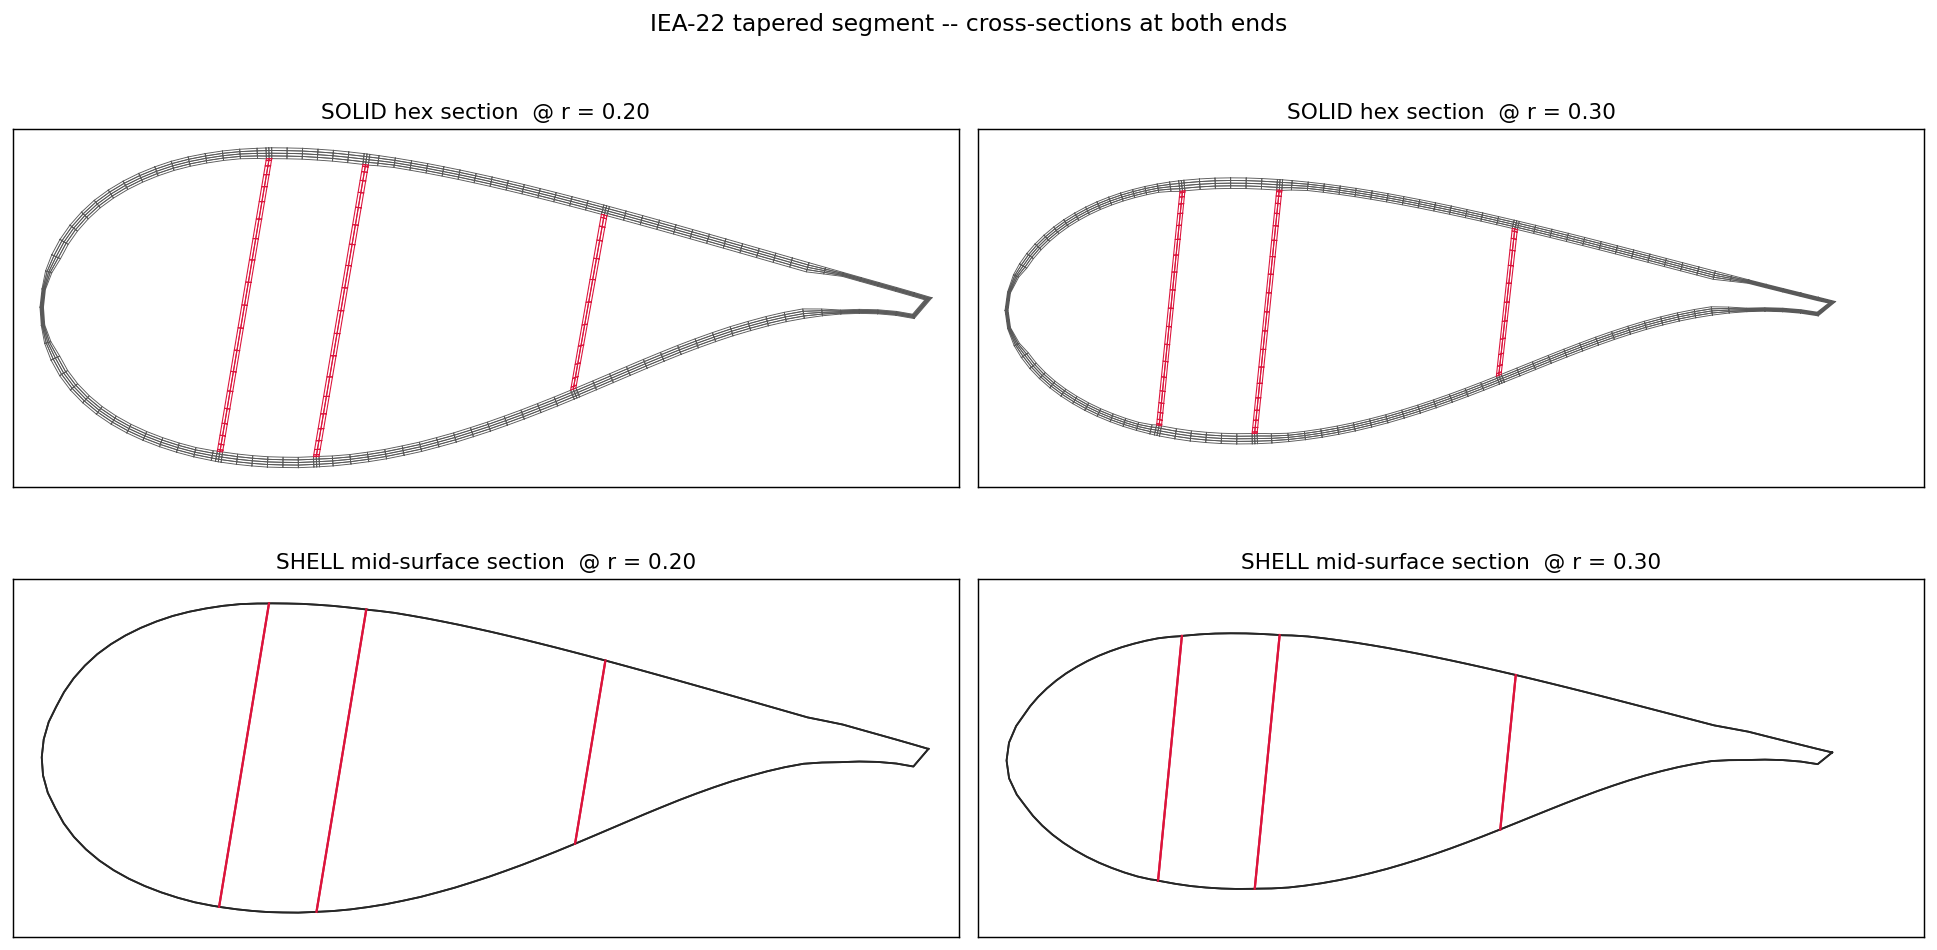

In [3]:
# cross-sections at BOTH ends -- solid (through-thickness layers + webs) and shell
display(Image(filename=os.path.join(OUT, "iea22_sections.png")))

## The structured hex solid

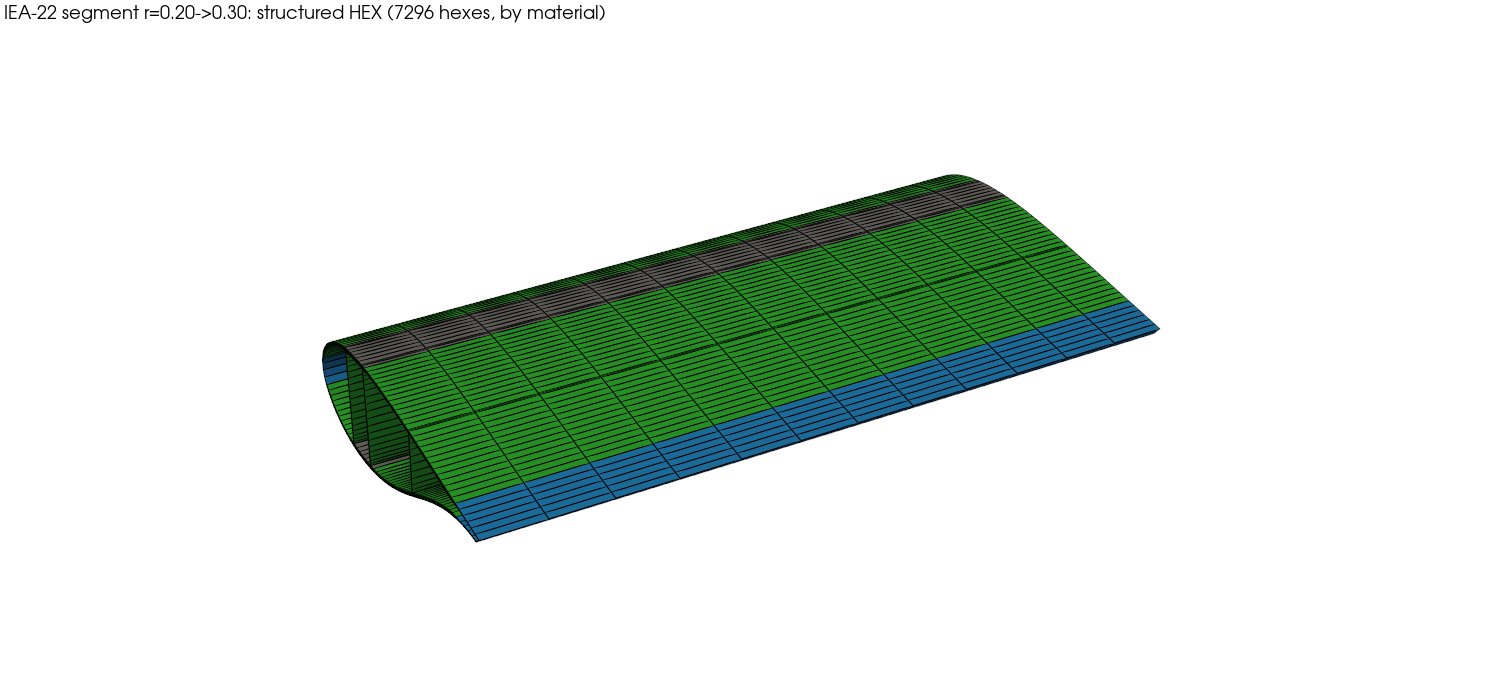

In [4]:
# the structured hex solid, shaded faces + element edges (colored by material)
display(Image(filename=os.path.join(OUT, "iea22_solid_3d.png")))

## The equivalent mid-surface shell

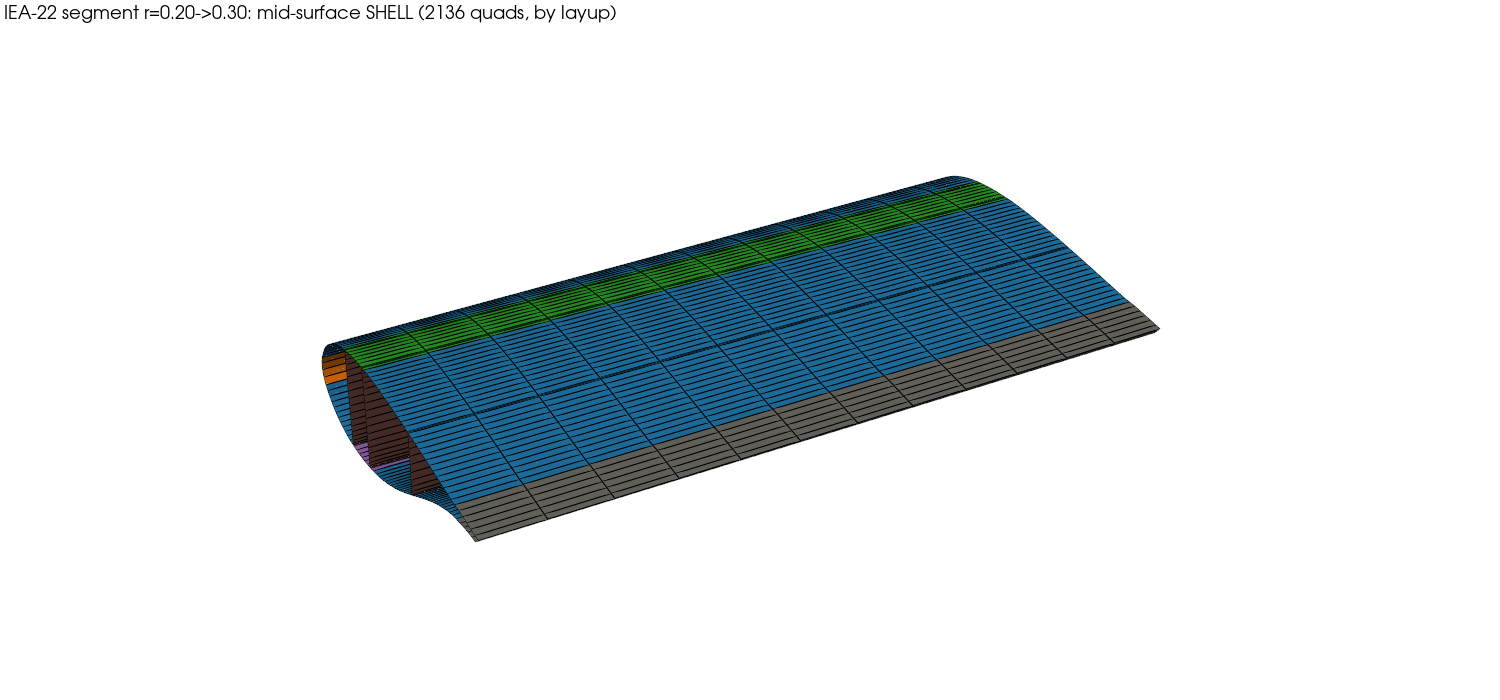

In [5]:
# the equivalent mid-surface shell (colored by layup)
display(Image(filename=os.path.join(OUT, "iea22_shell_3d.png")))

## The exported SG YAML

In [6]:
# the exported YAML is an OpenSG shell SG file -- show its STRUCTURE, not the mesh dump
import yaml
with open(os.path.join(OUT, "iea22_seg_shell.yaml")) as f:
    d = yaml.safe_load(f)
print("shell SG YAML  (keys: %s)" % ", ".join(d))
print("  nodes    : %d" % len(d["nodes"]))
print("  elements : %d" % len(d["elements"]))
print("  sets     : %d element sets (%s ...)" % (len(d["sets"]["element"]),
      ", ".join(s["name"] for s in d["sets"]["element"][:4])))
print("  sections : %d layups; e.g. %s -> %d plies" % (len(d["sections"]),
      d["sections"][0]["elementSet"], len(d["sections"][0]["layup"])))
print("  materials: %s" % ", ".join(m["name"] for m in d["materials"]))

shell SG YAML  (keys: nodes, elements, sets, sections, elementOrientations, materials)
  nodes    : 2275
  elements : 2136
  sets     : 6 element sets (layup_0, layup_1, layup_2, layup_3 ...)
  sections : 6 layups; e.g. layup_0 -> 4 plies
  materials: carbon_uniax, gelcoat, glass_biax, glass_triax, glass_uniax, medium_density_foam


## Notes

* **Strictly structured**: hoop skeleton × `nr` through-thickness layers × `nsp` span slices
  — no unstructured fill anywhere.
* The **shell conformity check differs from the solid one**: a branched mid-surface shell
  legitimately has T-junction edges shared by exactly **3** quads (skin-left + skin-right +
  web); the check asserts exactly `2 × n_webs × nsp` such edges and none shared by more.
* The two YAMLs feed the [OpenSG-TW](https://github.com/bagla0/OpenSG-TW) homogenizers
  (RM shell segment ↔ FEniCS 3-D solid) for the tapered Timoshenko 6×6.
* Refinement knobs (`iea22_segment.py`): `MESH` (hoop), `NR` (through-thickness), `NSP`
  (span), `NW` (junction band). Change the station radii with
  `python examples/IEA/iea22_segment.py <windio.yaml> <r1> <r2>`.